# Forest Fire Cellular Automaton
### Lesson 4, Section 2

In this notebook we will:
1. Understand the three-state forest fire model
2. Implement **fire detection** in a neighbourhood
3. Implement the **cell update rule**
4. Build the full simulation loop
5. Visualise the spatial dynamics and population over time
6. Explore **self-organised criticality** by varying parameters

---

## 0 · Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import clear_output
import time

In [2]:
# Colour palette: Empty (brown-grey), Tree (green), Burning (orange-red)
GROUND = np.array([76, 66, 70]) / 255
TREES  = np.array([118, 176, 65]) / 255
FIRE   = np.array([228, 87, 46]) / 255
FOREST_CMAP = ListedColormap([GROUND, TREES, FIRE])

def show_forest(grid, title='', ax=None):
    """Display a forest fire grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid, cmap=FOREST_CMAP, vmin=0, vmax=2)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
    return ax

---
## 1 · The Model

Each cell in the grid is in one of **three states**:

| State | Value | Meaning |
|-------|-------|---------|
| Empty | 0 | Bare ground |
| Tree  | 1 | Living tree |
| Burning | 2 | Tree on fire |

### Update rules (applied simultaneously to all cells):

1. **Burning → Empty**: A burning tree always burns out.
2. **Tree → Burning**: If any neighbour is burning, or with probability $p_{\text{ignition}}$ (lightning).
3. **Empty → Tree**: A new tree grows with probability $p_{\text{planting}}$.

> The interplay between slow growth and sudden destruction creates **self-organised criticality**.

---
## 2 · Step 1: Detecting Fire in the Neighbourhood

We need a function that checks whether **any** of the 8 neighbours (Moore neighbourhood) is on fire (state 2).

In [3]:
def detect_fire(row, col, grid):
    """Check if there is a burning cell in the Moore neighbourhood.
    
    Parameters
    ----------
    row, col : int
        Position of the cell to check.
    grid : np.ndarray
        The forest grid (0=empty, 1=tree, 2=burning).
    
    Returns
    -------
    bool : True if any neighbour is burning.
    """
    height, width = grid.shape
    neighbourhood = grid[
        max(0, row - 1) : min(height, row + 2),
        max(0, col - 1) : min(width, col + 2)
    ]
    return bool(np.max(neighbourhood) == 2)

### Test: Fire detection

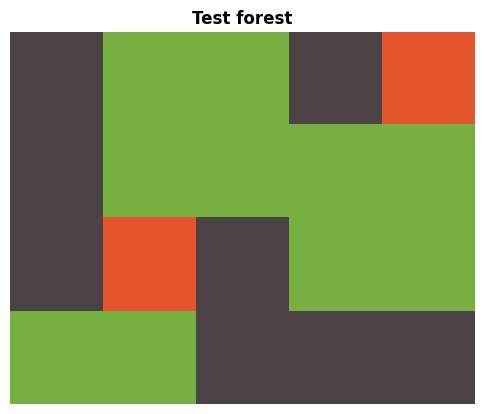

detect_fire(1, 1): True  (expected: True — neighbour (2,1) is burning)
detect_fire(3, 4): False  (expected: False)
detect_fire(0, 4): True  (expected: True — cell itself is burning)
detect_fire(1, 3): True  (expected: True)


In [4]:
test_forest = np.array([
    [0, 1, 1, 0, 2],
    [0, 1, 1, 1, 1],
    [0, 2, 0, 1, 1],
    [1, 1, 0, 0, 0],
])

show_forest(test_forest, title='Test forest')
plt.show()

# Cell (1,1) — neighbours include (2,2) which is empty, but (0,2) is tree...
# Actually (2,1)=2, so yes fire nearby
print(f'detect_fire(1, 1): {detect_fire(1, 1, test_forest)}  (expected: True — neighbour (2,1) is burning)')
# Cell (3, 4) — far from fire
print(f'detect_fire(3, 4): {detect_fire(3, 4, test_forest)}  (expected: False)')
# Cell (0, 4) — is itself burning
print(f'detect_fire(0, 4): {detect_fire(0, 4, test_forest)}  (expected: True — cell itself is burning)')
# Cell (1, 3) — neighbour (0,4)=2
print(f'detect_fire(1, 3): {detect_fire(1, 3, test_forest)}  (expected: True)')

---
## 3 · Step 2: Updating a Single Cell

Apply the transition rules based on the cell's current state and whether fire is nearby:

In [5]:
def update_cell(state, fire_nearby, p_planting, p_ignition):
    """Determine the next state of a forest cell.
    
    Parameters
    ----------
    state : int
        Current state: 0=empty, 1=tree, 2=burning.
    fire_nearby : bool
        Whether any neighbour is on fire.
    p_planting : float
        Probability of a new tree growing on empty ground.
    p_ignition : float
        Probability of spontaneous ignition (lightning).
    
    Returns
    -------
    int : next state
    """
    if state == 0:  # Empty
        return 1 if np.random.random() < p_planting else 0
    elif state == 1:  # Tree
        if fire_nearby or np.random.random() < p_ignition:
            return 2  # catches fire
        return 1
    else:  # Burning
        return 0  # burns out

### Test: Cell update

In [6]:
# Burning cell always becomes empty
print(f'Burning → {update_cell(2, False, 0.5, 0.5)}  (expected: 0)')

# Tree with fire nearby always catches fire
print(f'Tree + fire nearby → {update_cell(1, True, 0.0, 0.0)}  (expected: 2)')

# Tree with no fire and p_ignition=0 stays tree
print(f'Tree, no fire, p_ign=0 → {update_cell(1, False, 0.0, 0.0)}  (expected: 1)')

# Empty with p_planting=1 always grows tree
print(f'Empty, p_plant=1 → {update_cell(0, False, 1.0, 0.0)}  (expected: 1)')

Burning → 0  (expected: 0)
Tree + fire nearby → 2  (expected: 2)
Tree, no fire, p_ign=0 → 1  (expected: 1)
Empty, p_plant=1 → 1  (expected: 1)


---
## 4 · Step 3: Full Simulation Loop

Now combine everything: iterate over all cells, apply updates simultaneously.

In [7]:
def forest_fire_step(grid, p_planting, p_ignition):
    """Advance the forest fire model by one time step."""
    height, width = grid.shape
    new_grid = np.zeros_like(grid)
    for row in range(height):
        for col in range(width):
            fire_nearby = detect_fire(row, col, grid)
            new_grid[row, col] = update_cell(
                int(grid[row, col]), fire_nearby, p_planting, p_ignition
            )
    return new_grid

### Quick test: one step on a small grid

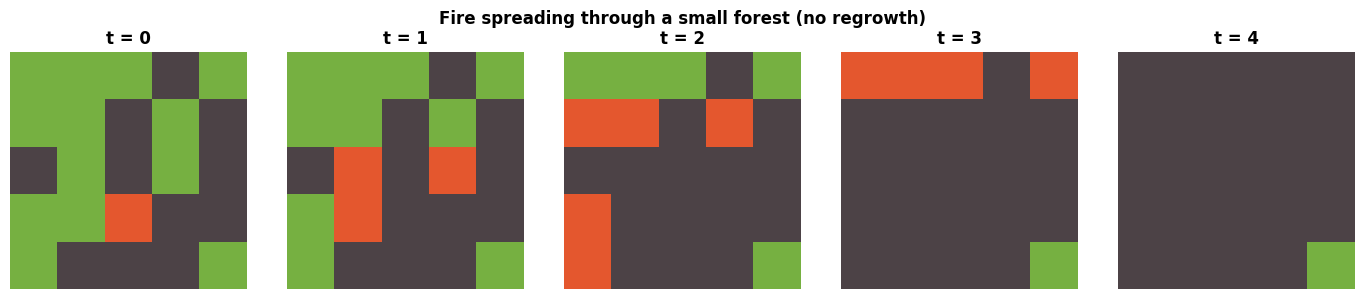

Fire spreads to neighbours each step, then burns out.


In [12]:
# Small manually-constructed grid
small = np.array([
    [1, 1, 1, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 2, 0, 0],
    [1, 0, 0, 0, 1],
])

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
np.random.seed(0)
for i in range(5):
    show_forest(small, title=f't = {i}', ax=axes[i])
    small = forest_fire_step(small, p_planting=0.0, p_ignition=0.0)
plt.suptitle('Fire spreading through a small forest (no regrowth)', fontweight='bold')
plt.tight_layout()
plt.show()
print('Fire spreads to neighbours each step, then burns out.')

---
## 5 · Full Animated Simulation

KeyboardInterrupt: 

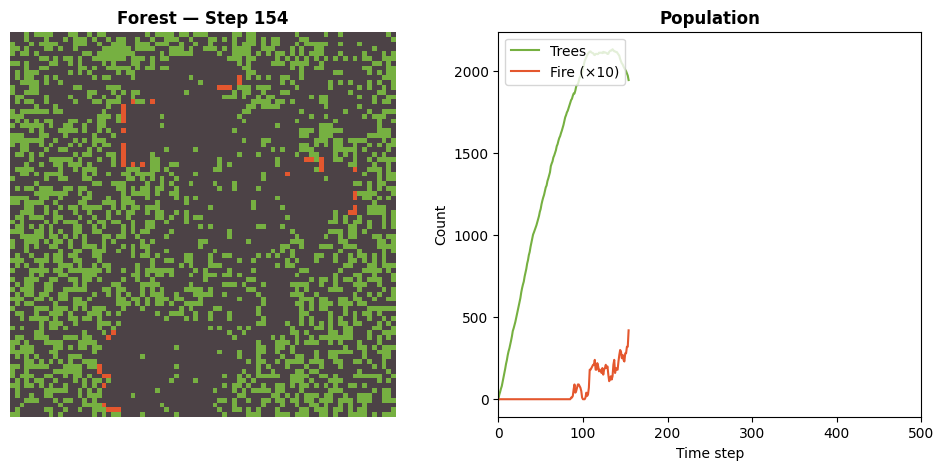

In [14]:
# Parameters
AREA = 80
STEPS = 500
P_PLANTING = 0.004
P_IGNITION = 0.00002

grid = np.zeros((AREA, AREA), dtype=int)

tree_count = []
fire_count = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for t in range(STEPS):
    tree_count.append(np.sum(grid == 1))
    fire_count.append(np.sum(grid == 2))
    
    ax1.clear()
    ax1.imshow(grid, cmap=FOREST_CMAP, vmin=0, vmax=2)
    ax1.set_title(f'Forest — Step {t}', fontweight='bold')
    ax1.axis('off')
    
    ax2.clear()
    ax2.plot(tree_count, color=TREES, lw=1.5, label='Trees')
    ax2.plot(np.array(fire_count) * 10, color=FIRE, lw=1.5, label='Fire (×10)')
    ax2.set_xlabel('Time step')
    ax2.set_ylabel('Count')
    ax2.set_title('Population', fontweight='bold')
    ax2.set_xlim(0, STEPS)
    ax2.legend(loc='upper left')
    
    clear_output(wait=True)
    display(fig)
    time.sleep(0.01)
    
    grid = forest_fire_step(grid, P_PLANTING, P_IGNITION)

plt.close(fig)
print(f'Done. Final tree count: {tree_count[-1]}')

---
## 6 · Parameter Exploration

The ratio $p_{\text{plant}} / p_{\text{ignition}}$ controls the balance between growth and destruction.

Let's compare three scenarios:

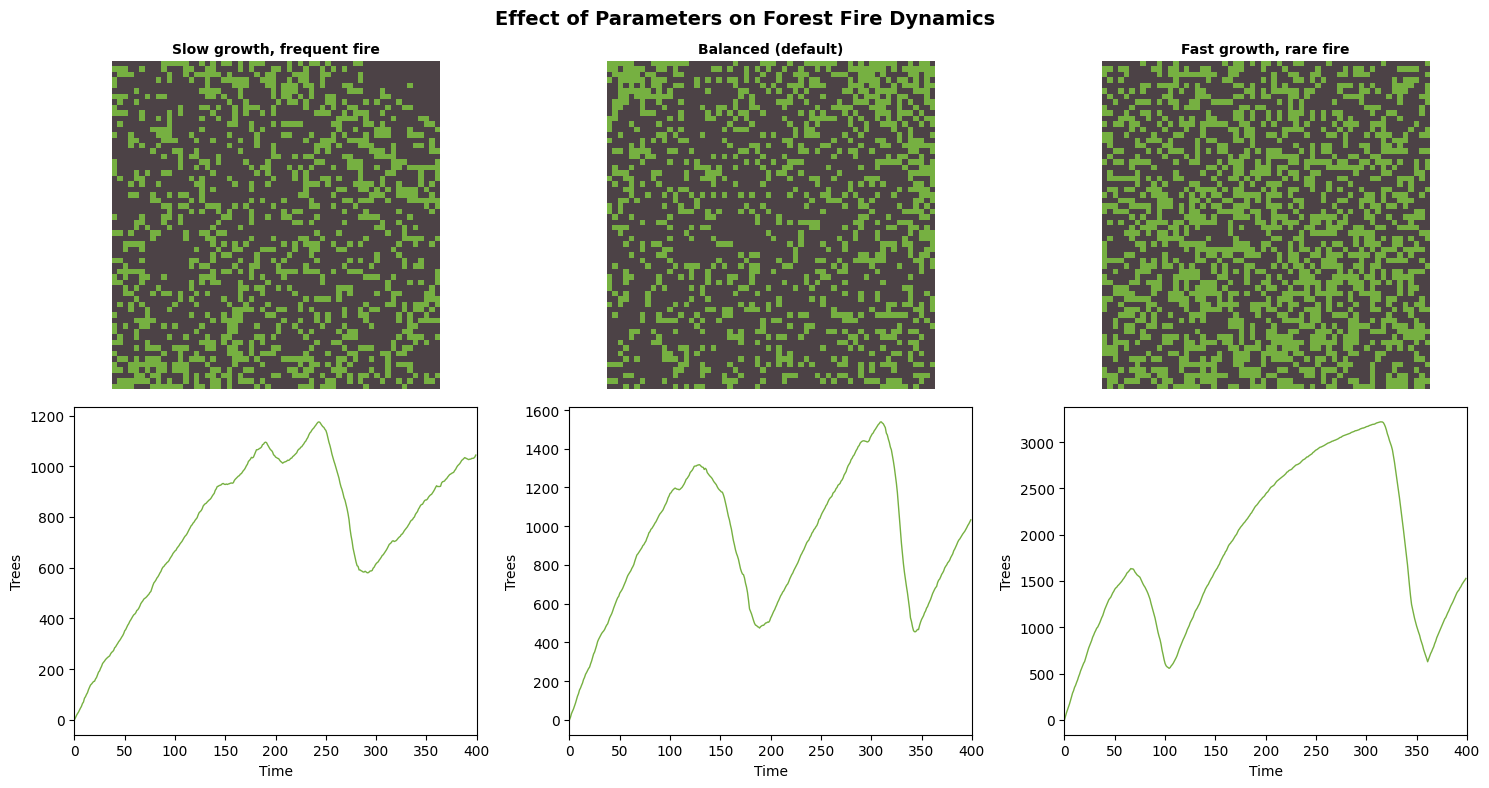

In [10]:
scenarios = [
    (0.002, 0.0001, 'Slow growth, frequent fire'),
    (0.004, 0.00002, 'Balanced (default)'),
    (0.01,  0.000005, 'Fast growth, rare fire'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_idx, (pp, pi, label) in enumerate(scenarios):
    np.random.seed(7)
    g = np.zeros((60, 60), dtype=int)
    tc = []
    for t in range(400):
        tc.append(np.sum(g == 1))
        g = forest_fire_step(g, pp, pi)
    
    axes[0, col_idx].imshow(g, cmap=FOREST_CMAP, vmin=0, vmax=2)
    axes[0, col_idx].set_title(label, fontweight='bold', fontsize=10)
    axes[0, col_idx].axis('off')
    
    axes[1, col_idx].plot(tc, color=TREES, lw=1)
    axes[1, col_idx].set_xlabel('Time')
    axes[1, col_idx].set_ylabel('Trees')
    axes[1, col_idx].set_xlim(0, 400)

plt.suptitle('Effect of Parameters on Forest Fire Dynamics', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 7 · What to Try Next

1. **Wind direction**: Modify `detect_fire` so that fire spreads more easily in one direction (e.g., only check cells to the east and south).
2. **Fire duration**: Instead of burning for exactly one step, let fire last 2–3 steps.
3. **Firebreaks**: Place permanent empty strips across the grid. Do they stop large fires?
4. **Initial conditions**: Start with a fully forested grid and a single ignition. How does the fire front propagate?
5. **Tree density threshold**: Run many simulations and find the critical initial density above which a single fire burns almost the entire grid (percolation threshold).

---

## 8 · Mini-Projects

### Project A: Fire Size Distribution
Track the size of each individual fire event (number of cells burned in one connected event). Run a long simulation (5000+ steps) and plot a histogram of fire sizes on a log-log scale. Does the distribution follow a power law?

### Project B: Percolation on a Static Forest
Generate a random forest with density $p$ (no regrowth). Ignite the entire left edge. Measure whether fire reaches the right edge. Sweep $p$ from 0.4 to 0.8 and find the **percolation threshold** — the critical density at which fire can cross the entire grid.

### Project C: Firefighting Strategy
Add a firefighter that can remove trees in a small radius. Compare strategies: (a) random removal, (b) remove trees near fire, (c) create firebreaks ahead of the fire front. Which strategy minimises total damage?